# 0.0 IMPORTS

In [49]:
import json
import random
import pickle
import requests
import inflection
import numpy      as np
import pandas     as pd
import xgboost    as xgb
import seaborn    as sns
import sweetviz   as sv

from flask                  import Flask, request, Response
from tabulate               import tabulate
from scipy                  import stats           as ss
from sklearn                import ensemble        as en
from sklearn                import neighbors       as ng
from sklearn                import preprocessing   as pp
from sklearn                import model_selection as ms
from sklearn                import linear_model    as lm
from sklearn                import metrics         as mt
from matplotlib             import pyplot          as plt

import warnings
warnings.filterwarnings( 'ignore' )

## 0.1 Loading dataset

In [2]:
df_raw = pd.read_csv('../data/raw/train.csv')
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 0.2 Herlper Functions

In [ ]:
def description_cols():
    description = [
    ['Variable', 'Definition'],
    ['id', 'Identificador do cliente'],
    ['Gender', 'Genero do cliente'],
    ['Age', 'Idade do cliente'],
    ['Driving_License', '0: Cliente não possui CNH, 1: Cliente já possui CNH'],
    ['Region_Code', 'Código da região do cliente'],
    ['Previously_Insured', '1: Cliente já possui seguro do veículo, 0: Cliente não possui seguro do veículo'],
    ['Vehicle_Age', 'Idade do veículo'],
    ['Vehicle_Damage', '1: Cliente já teve dano/acidente no carro, 0: Cliente nunca teve dano/acidente no carro'],
    ['Annual_Premium', 'Valor pago anualmente à empresa pelo seguro de saúde'],
    ['Policy_Sales_Channel', 'Código anônimo para contato do cliente'],
    ['Vintage', 'Número de dias desde que o cliente contratou o seguro de saúde'],
    ['Response', '1: Cliente interessado, 0: Cliente não interessado']
    ]

    print(tabulate(description, headers='firstrow', tablefmt='fancy_grid', showindex=True))

def cumulative_gain_curve(y_true, y_proba, class_label):
    y_true = np.array(y_true)
    y_score = y_proba[:, class_label]

    y_true_binary = (y_true == class_label).astype(int)

    sorted_index = np.argsort(y_score)[::-1]
    y_true_sorted = y_true_binary[sorted_index]

    gains = np.cumsum(y_true_sorted) / y_true_binary.sum()
    percentages = np.arange(1, len(y_true) + 1) / len(y_true)

    percentages = np.insert(percentages, 0, 0)
    gains = np.insert(gains, 0, 0)

    return percentages, gains


def precision_at_k(data, k=4000):
    data = data.sort_values('score', ascending=False).reset_index(drop=True)
    data = data.iloc[:k]

    precision = data['response'].sum() / k

    return precision


def recall_at_k(data, k=4000):
    data = data.sort_values('score', ascending=False).reset_index(drop=True)

    top_k = data.iloc[:k]

    recall = top_k['response'].sum() / data['response'].sum()

    return recall


def metrics_models(df, model_name, y_val, yhat_model, x_val, k=4000):
    data = x_val.copy()

    data['response'] = y_val.values if hasattr(y_val, 'values') else y_val

    # pega somente a probabilidade da classe 1
    data['score'] = yhat_model[:, 1]

    precision = precision_at_k(data, k=k)
    recall = recall_at_k(data, k=k)

    return pd.DataFrame({
        'Model Name': [model_name],
        'Precision at K': [precision],
        'Recall at K': [recall]
    })


def cramer_v(x, y):
    cm = pd.crosstab( x, y ).values
    n = cm.sum()
    r, k = cm.shape

    chi2 = ss.chi2_contingency( cm )[0]
    chi2corr = max( 0, chi2 - (k-1) * (r-1) / (n-1) )
    kcorr = k - (k-1)**2 / (n-1) 
    rcorr = r - (r-1)**2 / (n-1) 

    return float(np.sqrt( (chi2corr/n) / ( min( kcorr - 1, rcorr - 1 ) ) ))


def metrics_models(data, model_name, y_val, yhat, x_val):
    
    data = x_val.copy()
    data['response'] = y_val.copy()
    # Score
    data['score'] = yhat[:,1].tolist()
    # Sorting customers by propensity score
    data = data.sort_values('score', ascending=False)

    # Calculate Precision at K
    precision = precision_at_k(data, k=4000)
    # Calculate Recall at k
    recall =  recall_at_k(data, k=4000)

    return pd.DataFrame({'Model Name': model_name,
                         'Precision at K': precision,
                         'Recall at K': recall}, index=[0])



def cross_validation(model, x_train, y_train, k, data, Verbose=True):
    kfold = ms.StratifiedKFold(n_splits=k, shuffle=True, random_state=28)
    precision_list = []
    precision_k_list = []
    recall_k_list = []
    balanced_list = []
    i=1

    for train_cv, val_cv in kfold.split(x_train, y_train):
        if Verbose == True:
            print(f'Fold number: {i}/{k}')
        
        else:
            pass

        x_train_fold = x_train.iloc[train_cv]
        y_train_fold = y_train.iloc[train_cv]
        x_val_fold = x_train.iloc[val_cv]
        y_val_fold = y_train.iloc[val_cv]

        model_fit = model.fit(x_train_fold, y_train_fold.values.ravel())
        yhat = model.predict_proba(x_val_fold)
        yhat_1 = model.predict(x_val_fold)

        data = x_val_fold.copy()
        data['response'] = y_val_fold.copy()
        data['score'] = yhat[:,1].tolist()
        data = data.sort_values('score', ascending=False)

        precision_k = precision_at_k(data, k=4000)
        precision_k_list.append(precision_k)

        recall_k = recall_at_k(data, k=4000)
        recall_k_list.append(recall_k)

        precision = mt.precision_score(y_val_fold, yhat_1)
        precision_list.append(precision)

        balanced_accuracy = mt.balanced_accuracy_score(y_val_fold, yhat_1)
        balanced_list.append(balanced_accuracy)

        i+=1

    df = pd.DataFrame({'Model Name': type(model).__name__,
                       'Balanced Accuracy Mean': np.mean(balanced_list).round(4),
                       'Precision Mean': np.mean(precision_list).round(4),
                       'Precision STD': np.std(precision_list).round(4),
                       'Precision@k Mean': np.mean(precision_k_list).round(4),
                       'Precision@k STD': np.std(precision_k_list).round(4),
                       'Recall@k Mean': np.mean(recall_k_list).round(4),
                       'Recall@k STD': np.std(recall_k_list).round(4)},
                       index=[0])

    return df


def plot_cumulative_gain_manual(y_true, y_score, cutoff=0.3280, figsize=(16, 6)):
    # Converte para array
    y_true = np.array(y_true).ravel()
    y_score = np.array(y_score)

    # Se vier com duas colunas, pega a probabilidade da classe 1
    if y_score.ndim == 2:
        y_score = y_score[:, 1]

    # Ordena pela maior probabilidade de compra
    order = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[order]

    # Considera classe 1 como interessado
    y_true_sorted = (y_true_sorted == 1).astype(int)

    # Ganho acumulado
    cumulative_gain = np.cumsum(y_true_sorted) / y_true_sorted.sum()

    # Percentual da base
    percentage_sample = np.arange(1, len(y_true_sorted) + 1) / len(y_true_sorted)

    # Começar o gráfico do zero
    percentage_sample = np.insert(percentage_sample, 0, 0)
    cumulative_gain = np.insert(cumulative_gain, 0, 0)

    # Ponto do cutoff
    cutoff_index = int(np.ceil(cutoff * len(y_true_sorted)))
    gain_at_cutoff = cumulative_gain[cutoff_index]

    # Plot
    plt.figure(figsize=figsize)

    plt.plot(
        percentage_sample,
        cumulative_gain,
        label='Model - Class 1'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        color='black',
        label='Baseline'
    )

    plt.axvline(
        cutoff,
        color='green',
        ls='--',
        lw=3,
        label=f'Top {cutoff:.2%}'
    )

    plt.axhline(
        gain_at_cutoff,
        color='gray',
        ls='--',
        lw=2,
        label=f'Gain {gain_at_cutoff:.2%}'
    )

    plt.scatter(
        cutoff,
        gain_at_cutoff,
        color='red',
        s=80
    )

    plt.title('Cumulative Gain Curve')
    plt.xlabel('Percentage of Sample')
    plt.ylabel('Gain')
    plt.legend()
    plt.grid(True)

    plt.show()

    print(f'Top {cutoff:.2%} da base captura {gain_at_cutoff:.2%} dos interessados.')
    print(f'O modelo é {gain_at_cutoff / cutoff:.2f}x melhor que uma escolha aleatória.')



def plot_lift_curve_manual(y_true, y_score, cutoff=0.3280, figsize=(16, 6)):
    # Converte para array
    y_true = np.array(y_true).ravel()
    y_score = np.array(y_score)

    # Se vier com duas colunas, pega a probabilidade da classe 1
    if y_score.ndim == 2:
        y_score = y_score[:, 1]

    # Ordena pela maior probabilidade de compra
    order = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[order]

    # Considera classe 1 como interessado
    y_true_sorted = (y_true_sorted == 1).astype(int)

    # Percentual acumulado da base
    percentage_sample = np.arange(1, len(y_true_sorted) + 1) / len(y_true_sorted)

    # Ganho acumulado
    cumulative_gain = np.cumsum(y_true_sorted) / y_true_sorted.sum()

    # Lift = ganho acumulado / percentual da base
    lift = cumulative_gain / percentage_sample

    # Adiciona o ponto inicial
    percentage_sample = np.insert(percentage_sample, 0, 0)
    lift = np.insert(lift, 0, lift[0])

    # Lift no cutoff
    cutoff_index = int(np.ceil(cutoff * len(y_true_sorted)))
    lift_at_cutoff = lift[cutoff_index]

    plt.figure(figsize=figsize)

    plt.plot(
        percentage_sample,
        lift,
        label='Model - Class 1'
    )

    # Baseline da Lift Curve é 1
    plt.axhline(
        y=1,
        linestyle='--',
        color='black',
        label='Baseline'
    )

    plt.axvline(
        cutoff,
        color='green',
        ls='--',
        lw=3,
        label=f'Top {cutoff:.2%}'
    )

    plt.scatter(
        cutoff,
        lift_at_cutoff,
        color='red',
        s=80
    )

    plt.title('Lift Curve')
    plt.xlabel('Percentage of Sample')
    plt.ylabel('Lift')
    plt.legend()
    plt.grid(True)

    plt.show()

    print(f'Top {cutoff:.2%} da base possui lift de {lift_at_cutoff:.2f}x.')    

# 1.0 DATA DESCRIPTION

## 1.1 Description

In [4]:
description_cols()

╒════╤══════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════╕
│    │ Variable             │ Definition                                                                              │
╞════╪══════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════╡
│  0 │ id                   │ Identificador do cliente                                                                │
├────┼──────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────┤
│  1 │ Gender               │ Genero do cliente                                                                       │
├────┼──────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────┤
│  2 │ Age                  │ Idade do cliente                                                                        │
├────┼──────────────────────┼───────────

## 1.2 Data Dimension

In [5]:
df_raw.columns = df_raw.columns.str.lower()
df1 = df_raw

In [6]:
print('Number of row : {}'.format(df1.shape[0]))
print('Number of columns : {}'.format(df1.shape[1]))

Number of row : 381109
Number of columns : 12


## 1.3 Data Types

In [7]:
df1.dtypes

id                        int64
gender                      str
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age                 str
vehicle_damage              str
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

## 1.4 Check NA

In [8]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

## 1.5 Data Descriptive

In [9]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64','datetime64[ns]'])

In [10]:
#central tendency - mediam, mean
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

#dispersion - std, min, max, range, skew, kurtose
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(np.min)).T
d3 = pd.DataFrame(num_attributes.apply(np.max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenar
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,0.000000,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,0.672539,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-21.595182,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-0.115266,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,0.167747,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-0.900008,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,0.003030,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906,3.298788


# 2.0 FEATURE ENGINEERING

In [11]:
df2 = df1.copy()

In [12]:
# vehicle age
df2['vehicle_age'] = df2['vehicle_age'].apply(lambda x:'over_2_years' if x== '> 2 Years' else 'between_1_2_years' if x =='1-2 Year' else 'below_1_year')
# vehicle damage
df2['vehicle_damage'] = df2['vehicle_damage'].apply(lambda x:1 if x =='Yes' else 0)

In [13]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,over_2_years,1,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,between_1_2_years,0,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,over_2_years,1,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,below_1_year,0,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,below_1_year,0,27496.0,152.0,39,0


# 3.0 DATA FILTERING

In [14]:
df3 = df2.copy()
# Após analisar os dados, não foram identificadas condições que exigissem a aplicação de filtros. Não há outliers aparentes que precisem ser removidos.

# 4.0 EDA

In [15]:
df4 = df3.copy()

## 4.1 Analise univariada

In [16]:
df4.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='str')

### 4.1.0 Numericals

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'driving_license'}>],
       [<Axes: title={'center': 'region_code'}>,
        <Axes: title={'center': 'previously_insured'}>,
        <Axes: title={'center': 'annual_premium'}>],
       [<Axes: title={'center': 'policy_sales_channel'}>,
        <Axes: title={'center': 'vintage'}>,
        <Axes: title={'center': 'response'}>]], dtype=object)

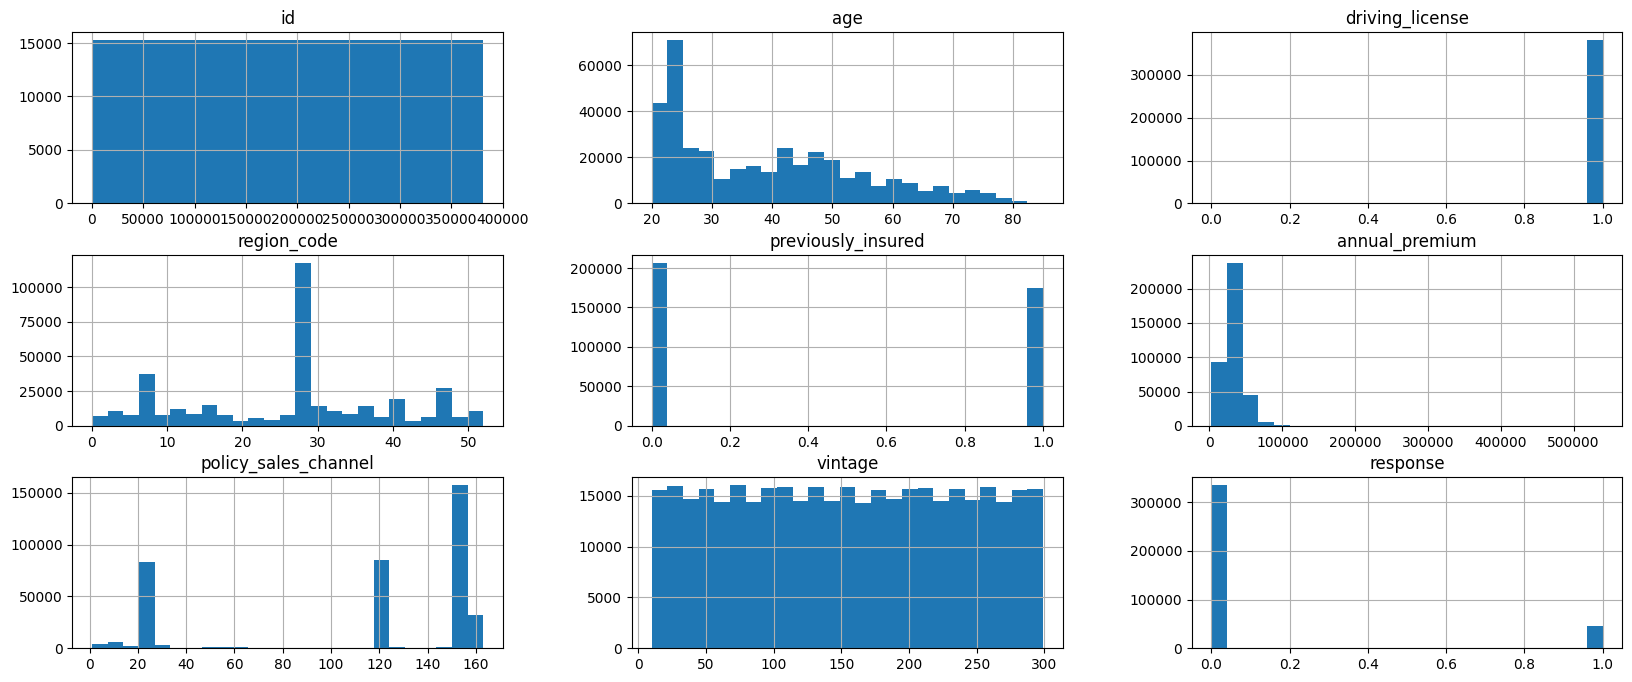

In [17]:
num_attributes.hist(bins=25,figsize=(20,8))

### 4.1.00 Categoricals

In [18]:
cat_attributes.apply(lambda x: x.unique().shape[0])

gender            2
vehicle_age       3
vehicle_damage    2
dtype: int64

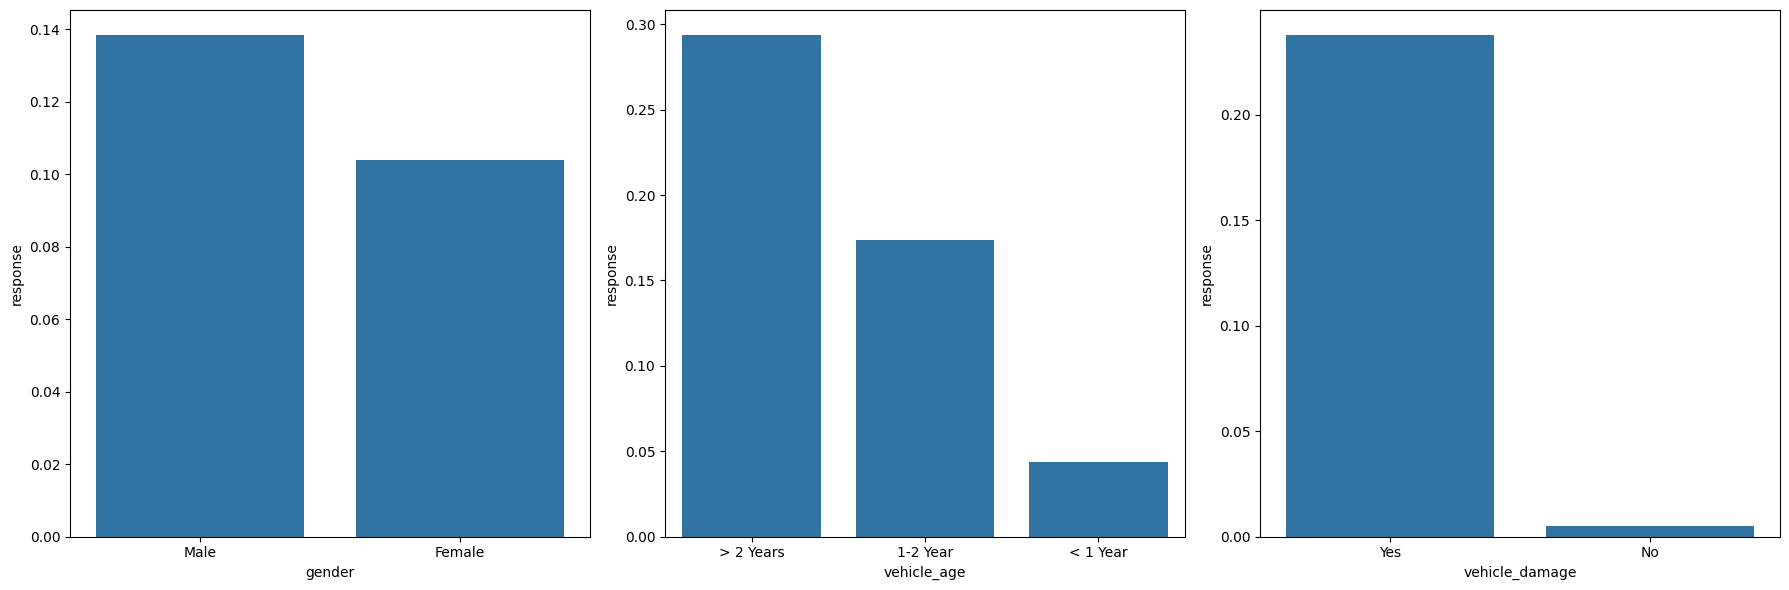

In [19]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
sns.barplot(x='gender', y='response', data=df1, errorbar=None)

plt.subplot(1,3,2)
sns.barplot(x='vehicle_age', y='response', data=df1, errorbar=None)

plt.subplot(1,3,3)
sns.barplot(x='vehicle_damage', y='response', data=df1, errorbar=None)

plt.tight_layout()
plt.show()

## 4.2 Analise bivariada

### 4.2.1 age

<Axes: xlabel='response', ylabel='age'>

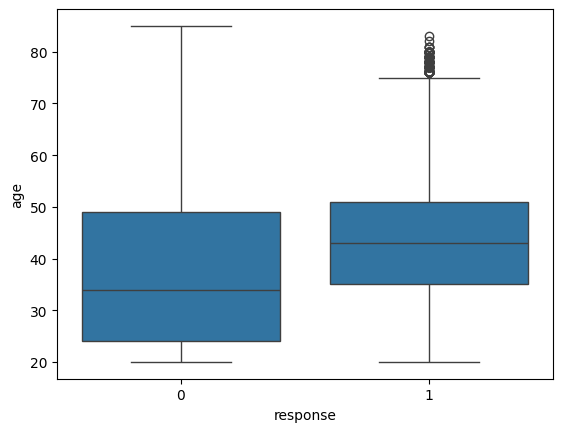

In [ ]:
# Existe uma grande concentração de clientes não interessados, cerca de 25.000 registros, na faixa etária de 20 a 25 anos.

# Já entre os clientes interessados, há uma quantidade menor de registros, cerca de 1.750, com maior concentração na faixa de 35 a 50 anos.

# Essa variável parece ser útil para diferenciar as duas classes, embora apresente desbalanceamento.

sns.boxplot(x='response', y='age', data=df4)

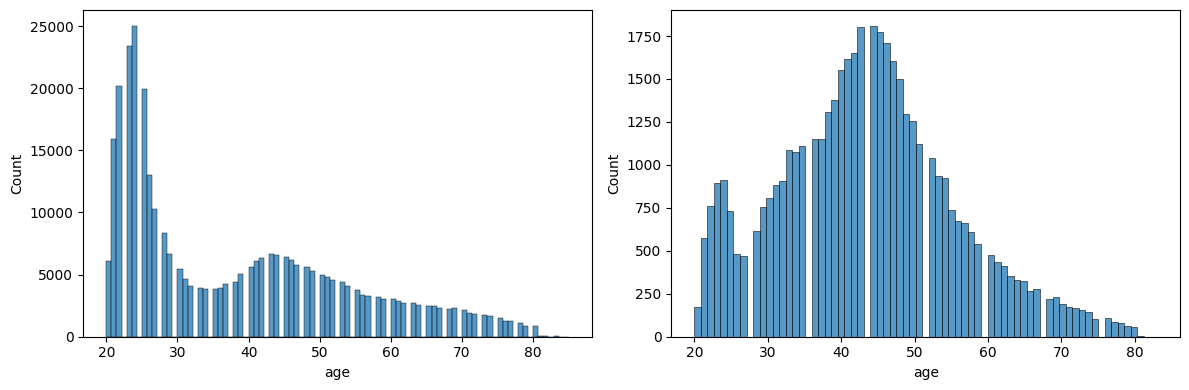

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = df4.loc[df4['response'] == 0, 'age']
sns.histplot(aux0, ax=ax1)

aux1 = df4.loc[df4['response'] == 1, 'age']
sns.histplot(aux1, ax=ax2)

plt.tight_layout()
plt.show()

### 4.2.2 Gender

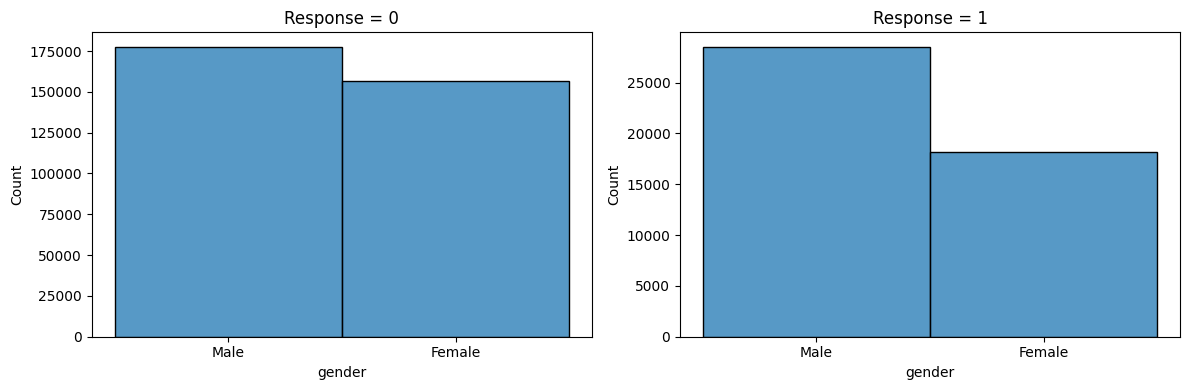

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = df4.loc[df4['response'] == 0, 'gender']
sns.histplot(aux0, ax=ax1)
ax1.set_title('Response = 0')

aux1 = df4.loc[df4['response'] == 1, 'gender']
sns.histplot(aux1, ax=ax2)
ax2.set_title('Response = 1')

plt.tight_layout()
plt.show()

In [27]:
df4[['gender', 'response']].value_counts(normalize=True).reset_index().sort_values('gender')

,gender,response,proportion
1,Female,0,0.411523
3,Female,1,0.047716
0,Male,0,0.465914
2,Male,1,0.074847


### 4.2.3 annual_premium

<Axes: xlabel='response', ylabel='annual_premium'>

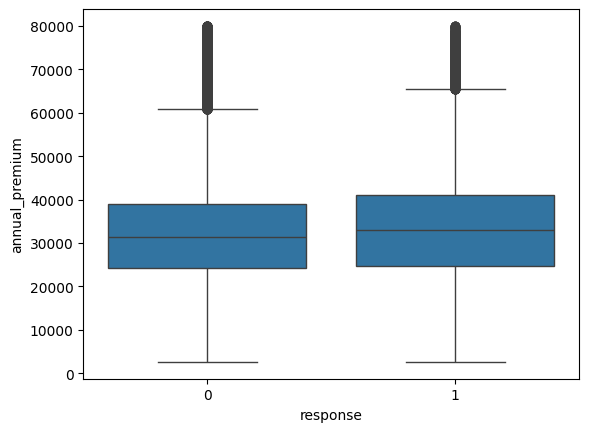

In [ ]:
# Essa variável, isoladamente, não parece ser relevante para a separação das classes. No entanto, pode apresentar algum valor quando combinada com outras variáveis.

# As distribuições possuem formatos semelhantes e medianas próximas, o que dificulta a identificação de grupos-alvo específicos.

aux2 = df4[df4['annual_premium'] < 80000]
sns.boxplot(x='response', y='annual_premium', data=aux2)

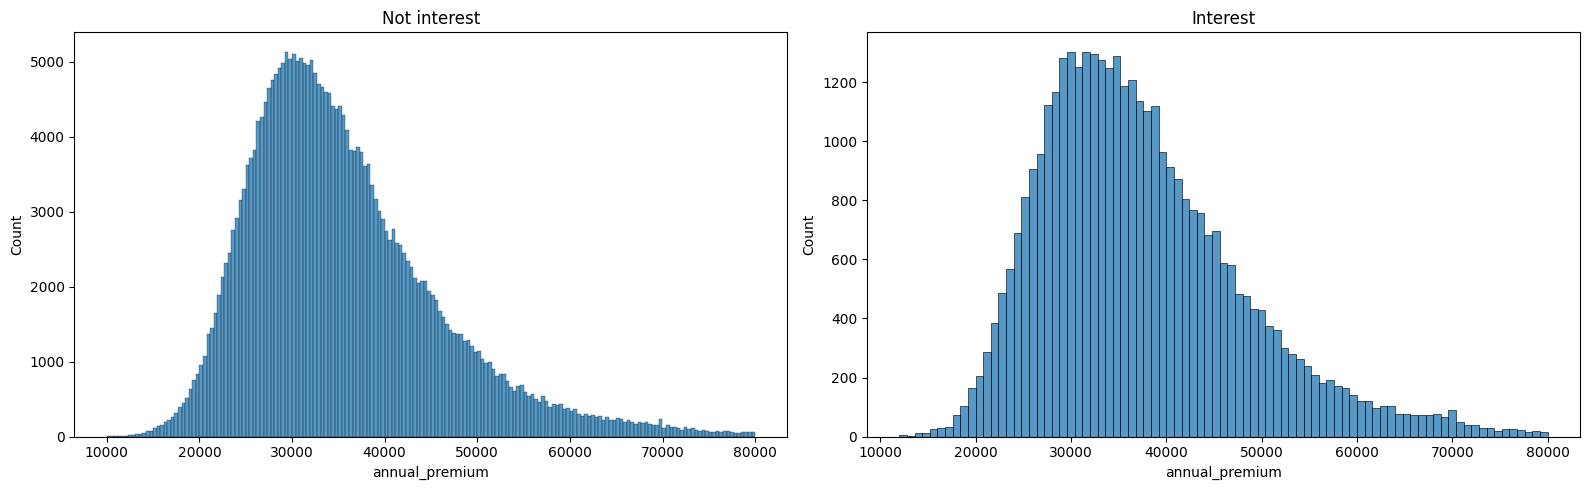

In [22]:
plt.figure(figsize=(16,5))
aux = df4[(df4['annual_premium'] > 10000) & (df4['annual_premium'] < 80000)]

plt.subplot(1, 2, 1)
plt.title('Not interest')
aux0 = aux.loc[aux['response'] == 0, 'annual_premium']
sns.histplot(aux0)

plt.subplot(1, 2, 2)
plt.title('Interest')
aux1 = aux.loc[aux['response'] == 1, 'annual_premium']
sns.histplot(aux1)

plt.tight_layout()
plt.show()

### 4.2.4 driving_license

<Axes: xlabel='response', ylabel='driving_license'>

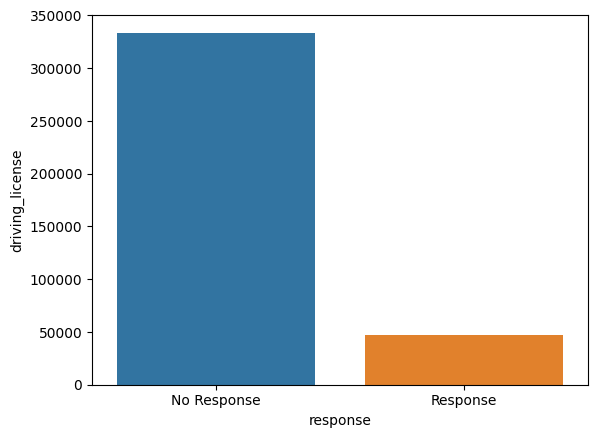

In [ ]:
# Essa variável apresenta uma segmentação clara entre os grupos e pode ser considerada importante. No entanto, sua análise deve ser combinada com a variável idade.

# Observa-se que há muitas pessoas com carteira de motorista que não demonstram interesse em seguro de automóvel. Esse comportamento deve ser investigado com mais profundidade para entender os possíveis motivos.

aux = df4[['driving_license', 'response']].groupby('response').sum().reset_index()
aux['response'] = aux['response'].map({0: 'No Response', 1: 'Response'})
sns.barplot(x='response', y='driving_license', data=aux, hue='response')

In [24]:
aux['driving_license_percent'] = aux['driving_license'] / aux['driving_license'].sum()
aux.head()

,response,driving_license,driving_license_percent
0,No Response,333628,0.877283
1,Response,46669,0.122717


### 4.2.5 region_code

<Axes: xlabel='region_code', ylabel='id'>

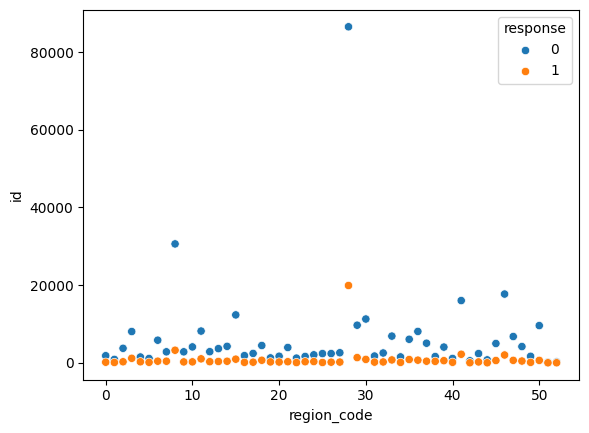

In [ ]:
# Essa variável não forma grupos ou clusters bem definidos.

# Isoladamente, ela não parece ser muito relevante. No entanto, pode se tornar útil quando combinada com outras variáveis.

# Observa-se que diferentes regiões apresentam níveis distintos de interesse em seguro.

aux4 = df4[['id','region_code','response']].groupby(['region_code','response']).count().reset_index()
sns.scatterplot(x='region_code', y='id', hue='response',data=aux4)

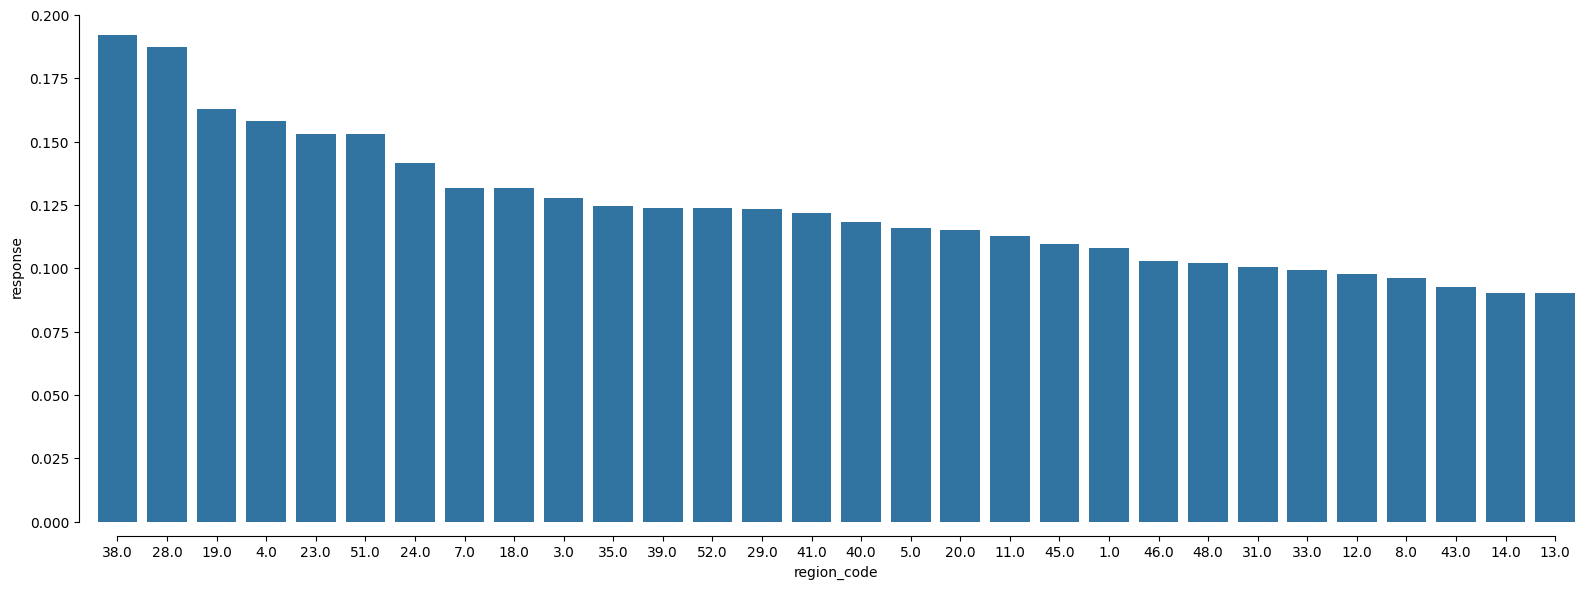

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
region_code,38.000000,28.000000,19.000000,4.000000,23.000000,51.000000,24.000000,7.000000,18.000000,3.000000,35.000000,39.0000,52.000000,29.000000,41.000000
response,0.192004,0.187163,0.162866,0.158245,0.153061,0.153005,0.141615,0.131747,0.131574,0.127662,0.124604,0.1236,0.123596,0.123362,0.121776


In [24]:
plt.figure(figsize=(16,6))
aux_region = df4[['region_code', 'response']].groupby('region_code').mean().sort_values(by='response', ascending=False).reset_index()
sns.barplot(x='region_code', y='response', data=aux_region, order = aux_region['region_code'].head(30))
sns.despine(offset=10, trim=True)

plt.tight_layout()
plt.show()
aux_region.head(15).T

### 4.2.6 previously_insured

In [25]:
# Clientes que já possuem seguro de veículo tendem a não demonstrar interesse em contratar o seguro oferecido pela empresa.

# A variável previously_insurance apresenta um possível vazamento de informação, pois praticamente antecipa a resposta do modelo.

# Sua correlação com a variável response é muito alta, indicando que clientes que já possuem seguro de veículo, em geral, não comprariam o seguro da empresa.

# Esse comportamento se aproxima de uma regra condicional simples: se o cliente já possui seguro, então tende a não comprar.

pd.crosstab(df4['previously_insured'], df4['response']).apply(lambda x: round((x/x.sum())*100, 2), axis=1)

response,0,1
previously_insured,,
0,77.45,22.55
1,99.91,0.09


In [ ]:
# 0 0 = Clientes sem seguro de saúde e sem interesse em seguro de automóvel

# 0 1 = Clientes sem seguro de saúde e com interesse em seguro de automóvel

# 1 0 = Clientes com seguro de saúde e sem interesse em seguro de automóvel

# 1 1 = Clientes com seguro de saúde e com interesse em seguro de automóvel

### 4.2.7 vehicle_age

In [ ]:
# Para veículos novos, com até 1 ano de uso, e para veículos entre 1 e 2 anos, observa-se uma boa diferenciação entre os grupos.

# Já para veículos mais antigos, os grupos apresentam comportamento semelhante.

df4[['vehicle_age','response']].value_counts(normalize=True).reset_index()

,vehicle_age,response,proportion
0,between_1_2_years,0,0.434285
1,below_1_year,0,0.413488
2,between_1_2_years,1,0.091328
3,over_2_years,0,0.029663
4,below_1_year,1,0.018897
5,over_2_years,1,0.012338


### 4.2.8 Vehicle Damage

In [26]:
# Clientes que já tiveram o veículo danificado apresentam maior tendência de contratar o seguro em comparação com clientes que não tiveram danos no veículo.

df4[['vehicle_damage', 'response']].value_counts(normalize=True).reset_index().sort_values('vehicle_damage')

,vehicle_damage,response,proportion
0,0,0,0.492547
3,0,1,0.002577
1,1,0,0.384890
2,1,1,0.119987


### 4.2.9 policy_sales_channel

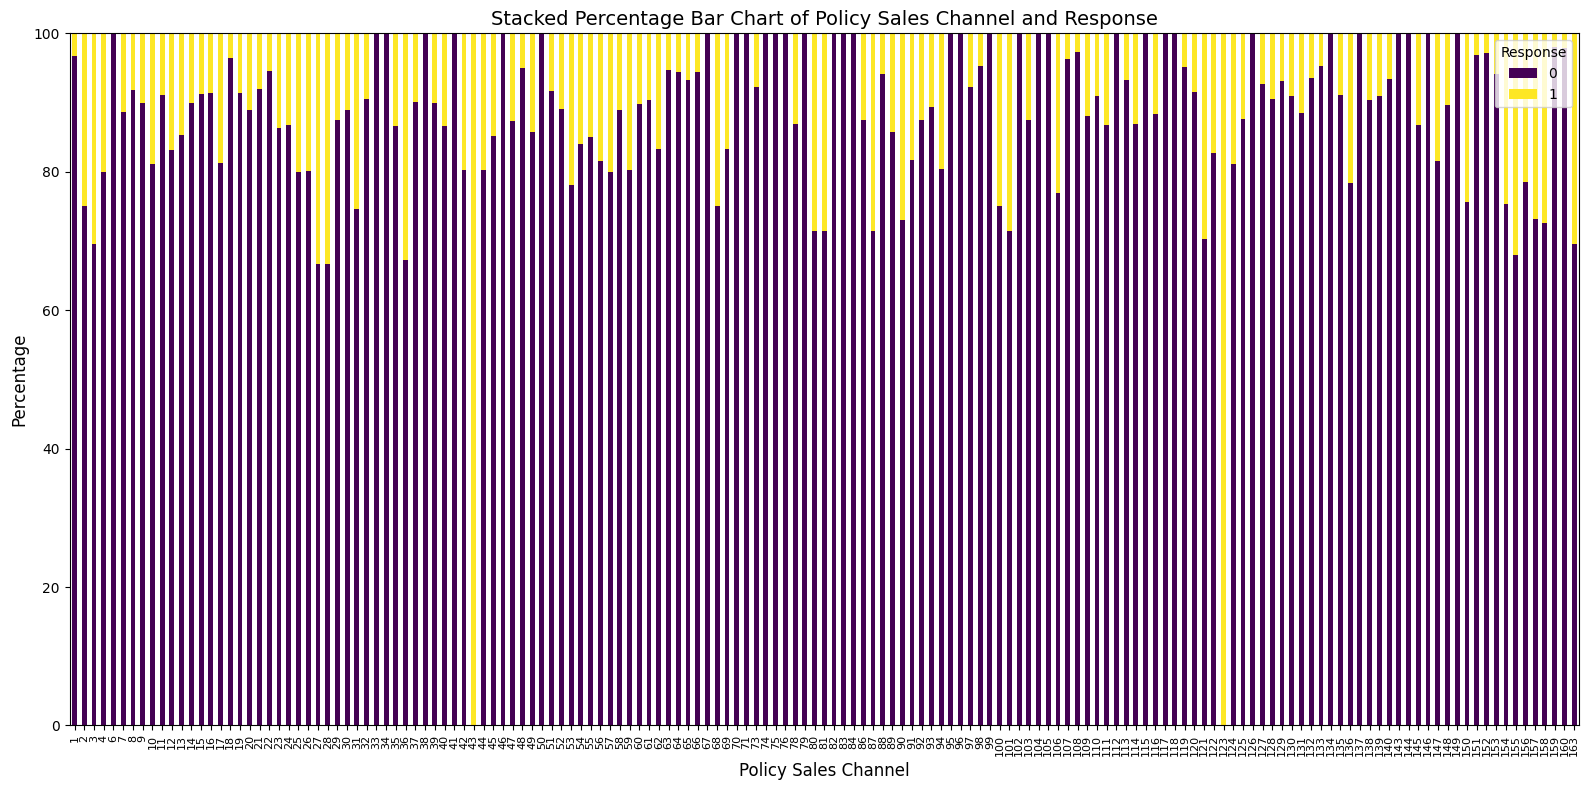

In [28]:
# Essa variável não forma grupos ou clusters bem definidos.

# Isoladamente, ela não parece ser muito relevante. No entanto, pode apresentar algum valor quando combinada com outras variáveis.

stacked_data = (df4.groupby(['policy_sales_channel', 'response']).size()
                .unstack(fill_value=0))

stacked_data_percentage = stacked_data.div(stacked_data.sum(axis=1),
                                           axis=0) * 100

stacked_data_percentage.plot(kind='bar', stacked=True, figsize=(16, 8),
                             colormap='viridis')

plt.title('Stacked Percentage Bar Chart of Policy Sales Channel and Response',
          fontsize=14)
plt.xlabel('Policy Sales Channel', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Response', loc='upper right', fontsize=10)
plt.xticks(range(len(stacked_data_percentage.index)), 
           labels=stacked_data_percentage.index.astype(int), 
           rotation=90, fontsize=8)
plt.tight_layout()

plt.show()

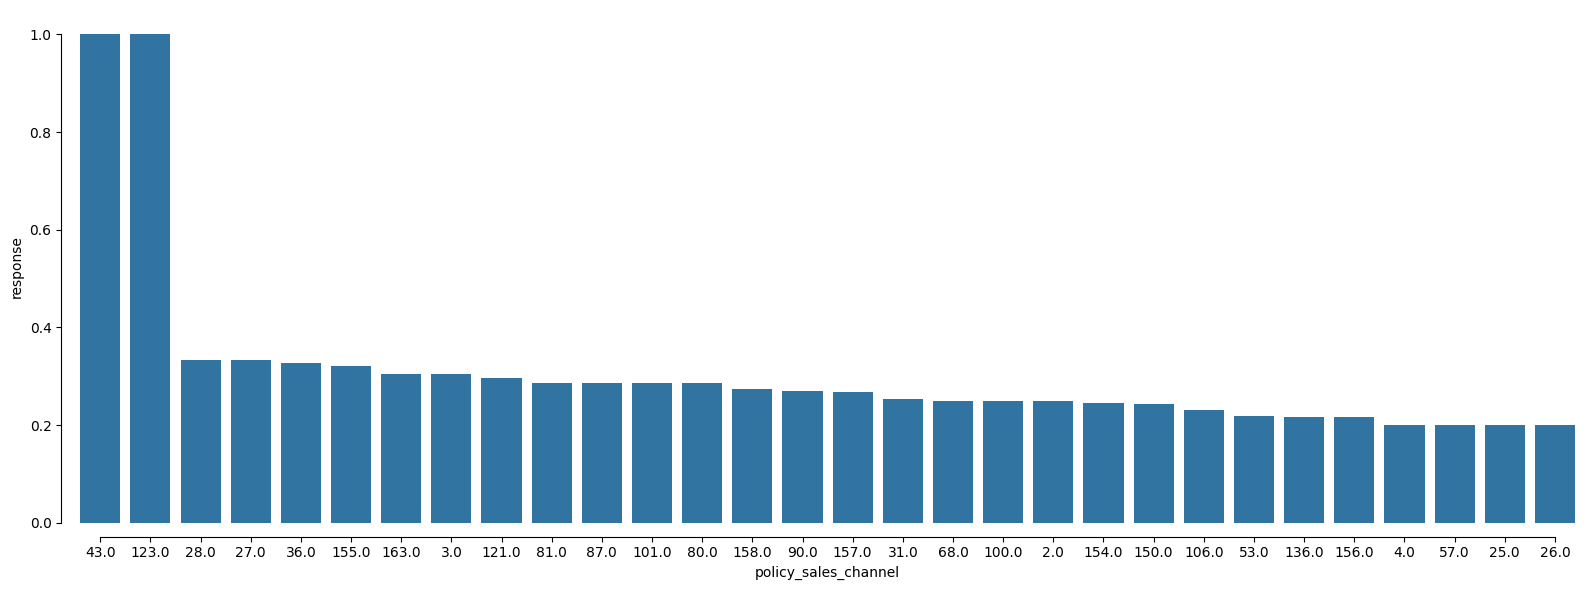

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
policy_sales_channel,43.0,123.0,28.000000,27.000000,36.000000,155.000000,163.000000,3.000000,121.000000,81.000000,87.000000,101.000000,80.000000,158.00000,90.000000
response,1.0,1.0,0.333333,0.333333,0.326923,0.320097,0.304183,0.304015,0.296875,0.285714,0.285714,0.285714,0.285714,0.27439,0.269231


In [29]:
plt.figure(figsize=(16,6))
aux_policy = df4[['policy_sales_channel', 'response']].groupby('policy_sales_channel').mean().sort_values(by='response', ascending=False).reset_index()
sns.barplot(x='policy_sales_channel', y='response', data=aux_policy, order = aux_policy['policy_sales_channel'].head(30))
sns.despine(offset=10, trim=True)

plt.tight_layout()
plt.show()
aux_policy.head(15).T

### 4.2.10 vintage

<Axes: xlabel='response', ylabel='vintage'>

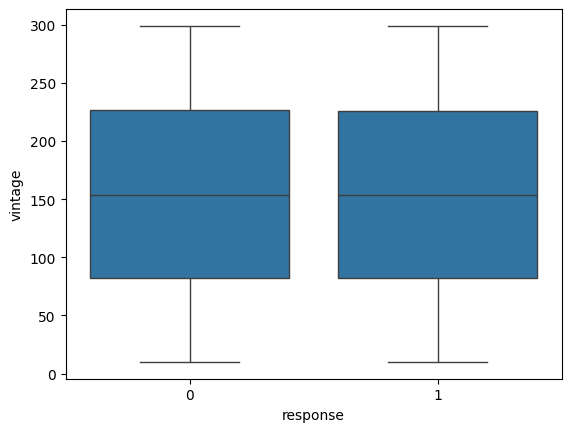

In [30]:
# Essa variável não apresenta segmentação clara entre os grupos, indicando que os dados são homogêneos.

# A distribuição é uniforme, sem concentrações relevantes em grupos específicos.

# Isoladamente, essa variável não parece ser relevante para diferenciar as classes. No entanto, pode apresentar algum valor quando combinada com outras variáveis.

sns.boxplot(x='response', y='vintage', data=df4)

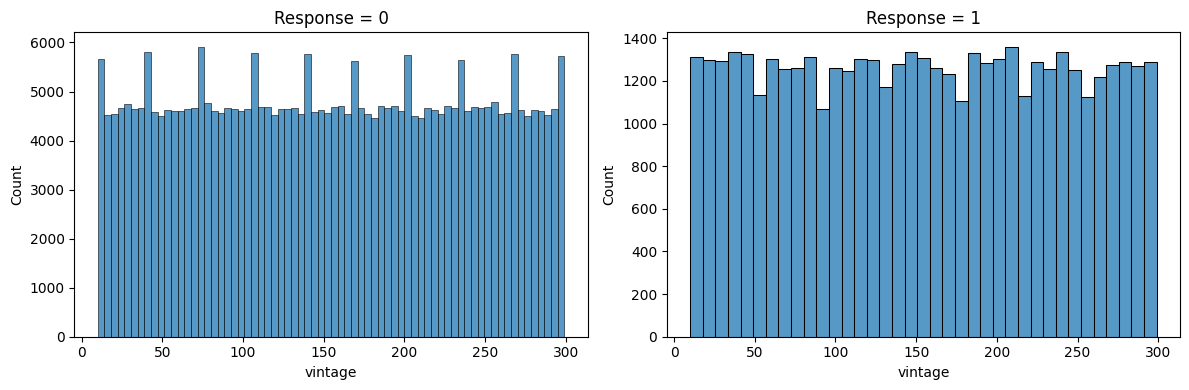

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux7 = df4.loc[df4['response'] == 0, 'vintage']
sns.histplot(aux7, ax=ax1)
ax1.set_title('Response = 0')

aux8 = df4.loc[df4['response'] == 1, 'vintage']
sns.histplot(aux8, ax=ax2)
ax2.set_title('Response = 1')

plt.tight_layout()
plt.show()

### 4.2.11 Response

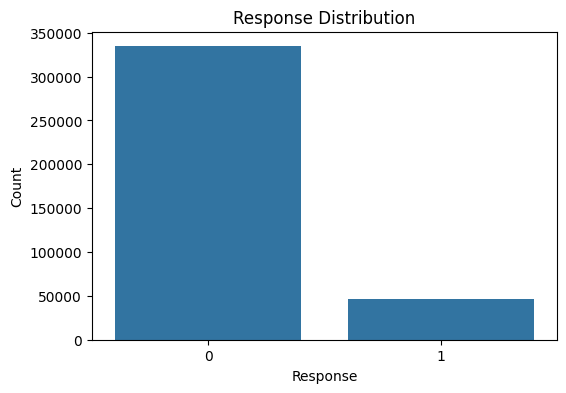

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='response', data=df4)

plt.title('Response Distribution')
plt.xlabel('Response')
plt.ylabel('Count')

plt.show()

In [22]:
df4['response'].value_counts(normalize=True) * 100

response
0    87.743664
1    12.256336
Name: proportion, dtype: float64

## 4.3 Analise multivariada

## 4.3.1 Numericas

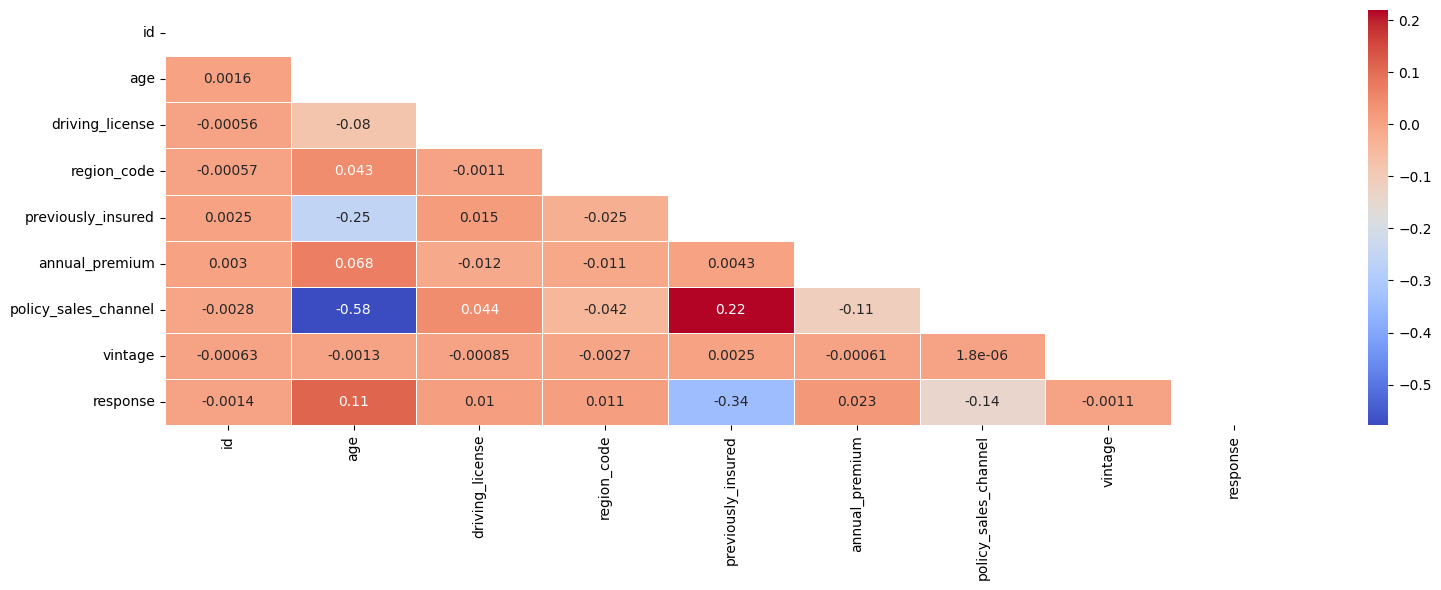

In [34]:
plt.figure(figsize=(16,6))

correlation = num_attributes.corr(method='pearson')

mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(
    correlation,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.tight_layout()
plt.show()

## 4.3.2 Categoricas

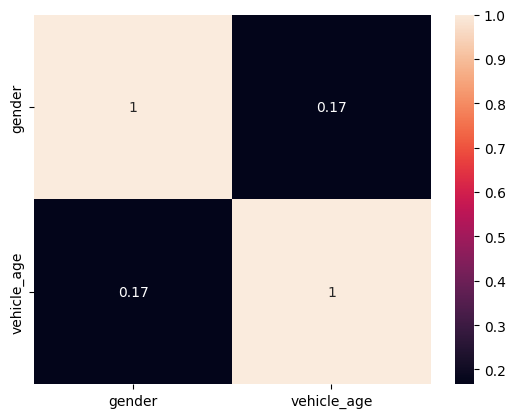

In [37]:
a = df4.select_dtypes(include='object')

# Calculate cramer v
a1 = cramer_v( a['gender'], a['gender'] )
a2 = cramer_v( a['gender'], a['vehicle_age'] )

a3 = cramer_v( a['vehicle_age'], a['gender'] )
a4 = cramer_v( a['vehicle_age'], a['vehicle_age'] )

# Final dataset
d = pd.DataFrame( {'gender': [a1, a2],
               'vehicle_age': [a3, a4],
               })

d = d.set_index(d.columns)

sns.heatmap(d, annot=True);

# 5.0 DATA PREPARATION

In [38]:
df5 = df4.copy()

In [39]:
x = df4.drop('response', axis=1)
y = df4['response'].copy()

x_train, x_validation, y_train, y_validation = ms.train_test_split(x, y, test_size=0.2, random_state=42)

x_val = x_validation.copy()
 
df5 = pd.concat([x_train, y_train], axis=1)

## 5.1 Standardization

In [40]:
ss = pp.StandardScaler()
#annual_premium
df5["annual_premium"] = ss.fit_transform(df5[["annual_premium"]])
pickle.dump(ss, open('../src/features/annual_premium_scaler.pkl','wb'))

## 5.2 Rescaling

In [41]:
#age (com o grafico histplot ficou evidente que precisa do rescaling)
mms_age = pp.MinMaxScaler()
df5["age"] = mms_age.fit_transform(df5[["age"]])
pickle.dump(mms_age, open('../src/features/age_scaler.pkl','wb'))

#vintage
mms_vintage = pp.MinMaxScaler()
df5["vintage"] = mms_vintage.fit_transform(df5[["vintage"]])
pickle.dump(mms_vintage, open('../src/features/vintage_scaler.pkl','wb'))

## 5.3 Encoder

In [42]:
# gender - One Hot Encoding / Target Encoding
target_encode_gender = df5.groupby( 'gender' )['response'].mean()
df5['gender'] = df5['gender'].map( target_encode_gender ).astype(float)
pickle.dump( target_encode_gender, open( '../src/features/target_encode_gender_scaler.pkl', 'wb' ) )

# region_code - Target Encoding / Frequency Encoding
target_encode_region_code = df5.groupby( 'region_code' )['response'].mean()
df5.loc[:, 'region_code'] = df5['region_code'].map( target_encode_region_code )
pickle.dump( target_encode_region_code, open( '../src/features/target_encode_region_code_scaler.pkl', 'wb' ) )

# vehicle_age - One Hot Encoding / Frequency Encoding
df5 = pd.get_dummies( df5, prefix='vehicle_age', columns=['vehicle_age'] )

# policy_sales_channel - Target Encoding / Frequency Encoding
fe_policy_sales_channel = df5.groupby( 'policy_sales_channel' ).size() / len( df5 )
df5.loc[:, 'policy_sales_channel'] = df5['policy_sales_channel'].map( fe_policy_sales_channel )
pickle.dump( fe_policy_sales_channel, open( '../src/features/fe_policy_sales_channel_scaler.pkl', 'wb' ) )

## 5.4 Validation Preparation

In [43]:
# gender
x_validation['gender'] = x_validation['gender'].map( target_encode_gender ).astype(float)

# age
x_validation['age'] = mms_age.transform(x_validation[['age']]).ravel().astype(float)

# region_code
x_validation.loc[:, 'region_code'] = x_validation.loc[:, 'region_code'].map( target_encode_region_code )

# vehicle_age
x_validation = pd.get_dummies( x_validation, prefix='vehicle_age', columns=['vehicle_age'] )

# annual_premium
x_validation.loc[:, 'annual_premium'] = ss.transform( x_validation[['annual_premium']].values )

# policy_sales_channel
x_validation.loc[:, 'policy_sales_channel'] = x_validation['policy_sales_channel'].map( fe_policy_sales_channel )

# vintage
x_validation['vintage'] = mms_vintage.transform(x_validation[['vintage']]).ravel().astype(float)

# fillna
x_validation = x_validation.fillna( 0 )

# 6.0 FEATURE SELECTION

In [44]:
# model definition
forest = en.ExtraTreesClassifier(n_estimators=100, random_state=0, n_jobs=-1)

# data preparation
x_train_n = df5.drop(['id', 'response'], axis=1)
y_train_n = y_train.values
forest.fit(x_train_n, y_train_n)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

Feature Ranking
                         feature  importance
0                        vintage    0.271439
0                 annual_premium    0.244243
0                            age    0.167122
0                    region_code    0.106572
0                 vehicle_damage    0.066297
0           policy_sales_channel    0.058204
0             previously_insured    0.058167
0       vehicle_age_below_1_year    0.013286
0  vehicle_age_between_1_2_years    0.007070
0                         gender    0.004465
0       vehicle_age_over_2_years    0.002635
0                driving_license    0.000500


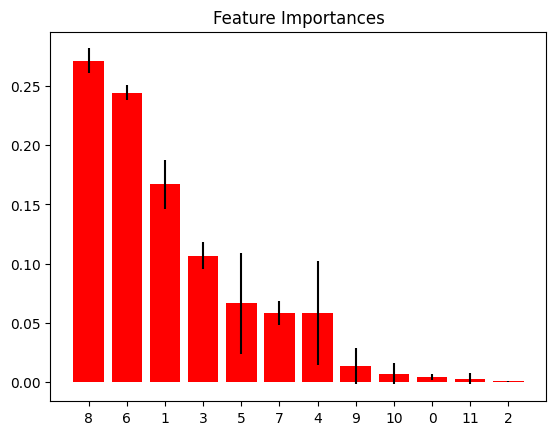

In [45]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print('Feature Ranking')
df = pd.DataFrame()
for i, j in zip(x_train_n, forest.feature_importances_):
    aux = pd.DataFrame({'feature': i, 'importance': j}, index=[0])
    df = pd.concat([df, aux], axis=0)

print(df.sort_values('importance', ascending=False))

# Plot the impurity-based feature importances of the forest
plt.figure()
plt.title('Feature Importances')
plt.bar(range(x_train_n.shape[1]), importances[indices], color='r', yerr=std[indices], align='center')
plt.xticks(range(x_train_n.shape[1]), indices)
plt.xlim([-1, x_train_n.shape[1]])
plt.show()

# 7.0 MACHINE LEARNING MODEL

In [51]:
# O objetivo não é apenas encontrar o melhor modelo para prever se uma pessoa irá comprar ou não.

# A proposta é criar um ranking de clientes, ordenando aqueles com maior probabilidade de compra.

# Por isso, buscamos um modelo que seja bom em ordenar essa lista de clientes. Nesse contexto, utilizamos métricas de ordenação, como a curva acumulada.

df6 = df5.copy()

cols_selected = ['vintage', 'annual_premium', 'age', 'region_code',
                 'vehicle_damage', 'policy_sales_channel',
                 'previously_insured']

x_train = df5[cols_selected]
x_val = x_validation[cols_selected]
y_val = y_validation.copy()

## 7.1 KNN

In [53]:
knn_model = ng.KNeighborsClassifier(n_neighbors=7)

knn_model.fit(x_train, y_train)

yhat_knn = knn_model.predict_proba(x_val)
y_score_knn = yhat_knn[:, 1]

## 7.2 Regressão Logistica

In [54]:
model_rl = lm.LogisticRegression(random_state=42)

model_rl.fit(x_train, y_train)

yhat_lr = model_rl.predict_proba(x_val)

y_score_lr = yhat_lr[:, 1]

## 7.3 Extra trees

In [55]:
#model definition
et = en.ExtraTreesClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

#model fit
et.fit(x_train, y_train)

#model predict
yhat_et = et.predict_proba(x_val)
y_score_et = yhat_et[:, 1]

## 7.4 Random Forest

In [75]:
model_rf = en.RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

model_rf.fit(x_train, y_train)

yhat_rf = model_rf.predict_proba(x_val)
y_score_rf = yhat_rf[:, 1]

## 7.5 XGBoost

In [62]:
xgb_model = xgb.XGBClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

# model training
xgb_model.fit(x_train, y_train)

# model prediction
yhat_xgb = xgb_model.predict_proba(x_val)
y_score_xgb = yhat_xgb[:, 1]

## 7.6 Comparando os modelos

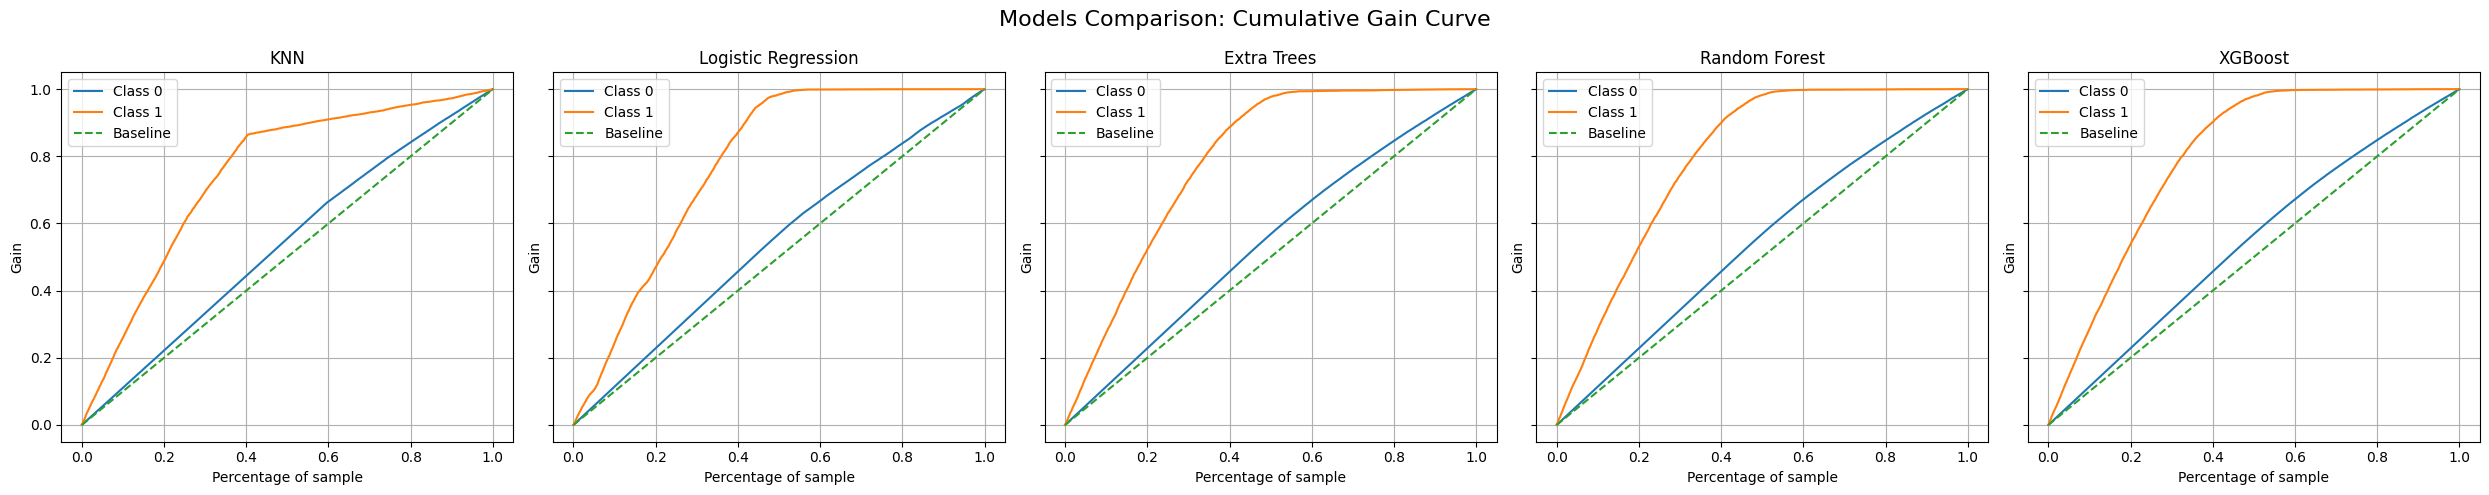

In [65]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

fig.suptitle('Models Comparison: Cumulative Gain Curve', fontsize=16)

models = {
    'KNN': yhat_knn,
    'Logistic Regression': yhat_lr,
    'Extra Trees': yhat_et,
    'Random Forest': yhat_rf,
    'XGBoost': yhat_xgb
}

for ax, (model_name, y_proba) in zip(axes, models.items()):

    # Class 0
    x_0, y_0 = cumulative_gain_curve(y_val, y_proba, class_label=0)
    ax.plot(x_0, y_0, label='Class 0')

    # Class 1
    x_1, y_1 = cumulative_gain_curve(y_val, y_proba, class_label=1)
    ax.plot(x_1, y_1, label='Class 1')

    # Baseline
    ax.plot([0, 1], [0, 1], linestyle='--', label='Baseline')

    ax.set_title(model_name)
    ax.set_xlabel('Percentage of sample')
    ax.set_ylabel('Gain')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# 8.0 MODEL PERFORMACE

In [71]:
knn_metrics = metrics_models(df6, 'KNN Classifier', y_val, yhat_knn, x_val)
lr_metrics = metrics_models(df6, 'Logistic Regression', y_val, yhat_lr, x_val)
et_metrics = metrics_models(df6, 'Extra Tree', y_val, yhat_et, x_val)
xgb_metrics = metrics_models(df6, 'XGBoost', y_val, yhat_xgb, x_val)
rf_metrics = metrics_models(df6, 'Random Forest', y_val, yhat_rf, x_val)

all_metrics = pd.concat([knn_metrics, lr_metrics, et_metrics, xgb_metrics,rf_metrics], axis=0)
all_metrics.sort_values(by='Precision at K', ascending=False)

,Model Name,Precision at K,Recall at K
0,XGBoost,0.36375,0.152788
0,Random Forest,0.35925,0.150898
0,Extra Tree,0.35025,0.147118
0,KNN Classifier,0.32675,0.137247
0,Logistic Regression,0.25800,0.108369


In [ ]:
knn_metrics_cv = cross_validation(knn_model, x_train, y_train, 5, df6, Verbose=False)
lr_metrics_cv = cross_validation(model_rl, x_train, y_train, 5, df6, Verbose=False)
et_metrics_cv = cross_validation(et, x_train, y_train, 5, df6, Verbose=False)
xgb_metrics_cv = cross_validation(xgb_model, x_train, y_train, 5, df6, Verbose=False)
rf_metrics_cv = cross_validation(model_rf, x_train, y_train, 5, df6, Verbose=False)
all_metrics_cv = pd.concat([knn_metrics_cv, lr_metrics_cv, et_metrics_cv, xgb_metrics_cv,rf_metrics_cv], axis=0)
all_metrics_cv.sort_values(by='Precision Mean', ascending=False)

,Model Name,Balanced Accuracy Mean,Precision Mean,Precision STD,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,XGBClassifier,0.5404,0.3514,0.0055,0.3424,0.0055,0.1841,0.0030
0,ExtraTreesClassifier,0.5515,0.3359,0.0010,0.3314,0.0020,0.1782,0.0011
0,KNeighborsClassifier,0.5480,0.3303,0.0045,0.3226,0.0064,0.1735,0.0034
0,LogisticRegression,0.5000,0.0000,0.0000,0.2747,0.0066,0.1477,0.0036


# 9.0 BUSINESS PERFORMANCE

In [ ]:
# Ao ordenar a base de clientes pela probabilidade de compra, observa-se que os 33% primeiros clientes do ranking concentram 80% de todos os interessados em adquirir seguro de veículo.

# Esse volume representa aproximadamente 20 mil contatos a serem realizados pela equipe de vendas.

# O modelo proposto apresenta um desempenho 2,5 vezes superior ao de uma seleção aleatória de clientes.

# Considerando um valor médio de US$ 1.000 por seguro vendido, o uso do modelo pode gerar cerca de US$ 26 milhões adicionais em receita quando comparado a uma abordagem aleatória.

## 9.1 Estrategia 1

In [77]:
all_y_true = []  
all_yhat = []    


precision_k_list = []
recall_k_list = []


k = 5
kf = ms.StratifiedKFold(n_splits=k, shuffle=True, random_state=28)


for train_index, val_index in kf.split(x_train, y_train):
    # Dividir os dados em treino e validação
    x_train_fold, x_val_fold = x_train.iloc[train_index], x_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Trainning
    model = xgb.XGBClassifier(n_estimators=1000, n_jobs=-1, random_state=42) 
    model.fit(x_train_fold, y_train_fold)
    
    # Predict
    yhat = model.predict_proba(x_val_fold)

    
    all_yhat.append(yhat[:, 1])  
    all_y_true.append(y_val_fold.values)

    
    data = x_val_fold.copy()
    data['response'] = y_val_fold.values
    data['score'] = yhat[:, 1]  
    data = data.sort_values('score', ascending=False)

    
    precision_k = precision_at_k(data, k=20000) 
    recall_k = recall_at_k(data, k=20000)

    precision_k_list.append(precision_k)
    recall_k_list.append(recall_k)


all_yhat = np.concatenate(all_yhat)
all_y_true = np.concatenate(all_y_true)


avg_precision_k = np.mean(precision_k_list)
avg_recall_k = np.mean(recall_k_list)

percent_of_dataset = 20000 / len(data)
print(f'Percentage of the dataset: {percent_of_dataset:.4f}')
print(f'Precision@k average: {avg_precision_k:.4f}')
print(f'Recall@k average: {avg_recall_k:.4f}')

Percentage of the dataset: 0.3280
Precision@k average: 0.2954
Recall@k average: 0.7943


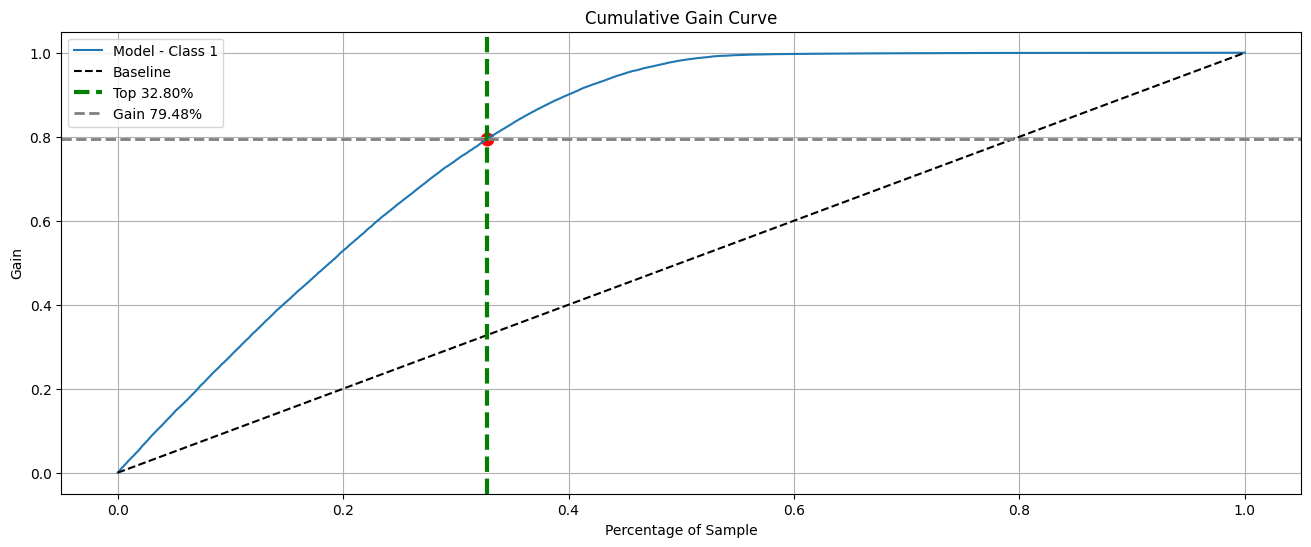

Top 32.80% da base captura 79.48% dos interessados.
O modelo é 2.42x melhor que uma escolha aleatória.


In [80]:
plot_cumulative_gain_manual(
    all_y_true,
    all_yhat,
    cutoff=0.3280,
    figsize=(16, 6)
)

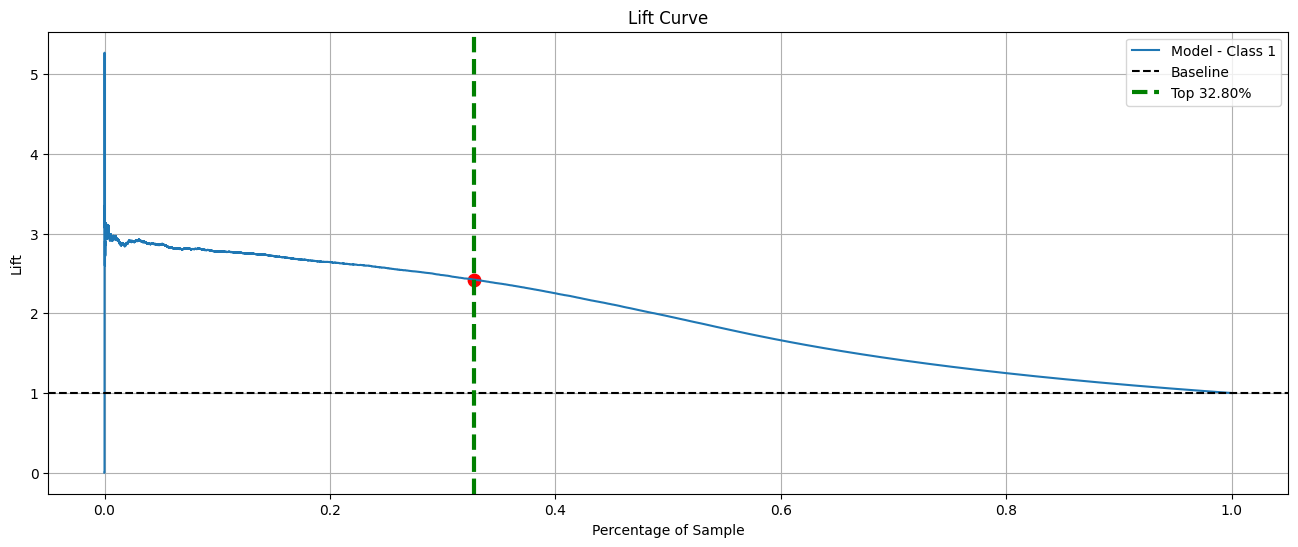

Top 32.80% da base possui lift de 2.42x.


In [82]:
plot_lift_curve_manual(
    all_y_true,
    all_yhat,
    cutoff=0.3280,
    figsize=(16, 6)
)

In [83]:
random_choice = (38/100) * len(data)
model = (80/100) * len(data)

revenue_rc = random_choice * 1000
revenue_m = model * 1000

print(f'Revenue with Random Choice: US$ {revenue_rc:,.2f}')
print(f'Revenue with Model: US$ {revenue_m:,.2f}')
print()
print(f'Difference: US$ {(revenue_m - revenue_rc):,.2f}')

Revenue with Random Choice: US$ 23,171,260.00
Revenue with Model: US$ 48,781,600.00

Difference: US$ 25,610,340.00


## 9.2 Estrategia 2

In [ ]:
# Ao ordenar a base de clientes pela probabilidade de compra, observa-se que os primeiros 44% dos clientes concentram 94% de todos os interessados em adquirir seguro de veículo.

# Esse volume representa aproximadamente 27 mil contatos a serem realizados pela equipe de vendas.

# O modelo proposto apresenta um desempenho 2,2 vezes superior ao de uma seleção aleatória de clientes.

# Considerando um valor médio de US$ 1.000 por seguro vendido, o uso do modelo pode gerar cerca de US$ 27 milhões adicionais em receita quando comparado a uma abordagem aleatória.

In [84]:
all_y_true = []  # Ture answers
all_yhat = []    # Predicts (probability)

# Lists for fold metrics
precision_k_list = []
recall_k_list = []

# Cross Validation number folds
k = 5
kf = ms.StratifiedKFold(n_splits=k, shuffle=True, random_state=28)

# Loop for cross validation
for train_index, val_index in kf.split(x_train, y_train):
    # Dividir os dados em treino e validação
    x_train_fold, x_val_fold = x_train.iloc[train_index], x_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Trainning
    model = xgb.XGBClassifier(n_estimators=1000, n_jobs=-1, random_state=42) 
    model.fit(x_train_fold, y_train_fold)
    
    # Predict
    yhat = model.predict_proba(x_val_fold)

    # Store predictions and true values
    all_yhat.append(yhat[:, 1])  
    all_y_true.append(y_val_fold.values)

    # Calculating score and classifying
    data = x_val_fold.copy()
    data['response'] = y_val_fold.values
    data['score'] = yhat[:, 1]  
    data = data.sort_values('score', ascending=False)

   
    precision_k = precision_at_k(data, k=27000)  
    recall_k = recall_at_k(data, k=27000)

    precision_k_list.append(precision_k)
    recall_k_list.append(recall_k)

# Concatenate results
all_yhat = np.concatenate(all_yhat)
all_y_true = np.concatenate(all_y_true)


avg_precision_k = np.mean(precision_k_list)
avg_recall_k = np.mean(recall_k_list)

percent_of_dataset = 27000 / len(data)
print(f'Percentage of the dataset: {percent_of_dataset:.4f}')
print(f'Precision@k average: {avg_precision_k:.4f}')
print(f'Recall@k average: {avg_recall_k:.4f}')

Percentage of the dataset: 0.4428
Precision@k average: 0.2603
Recall@k average: 0.9451


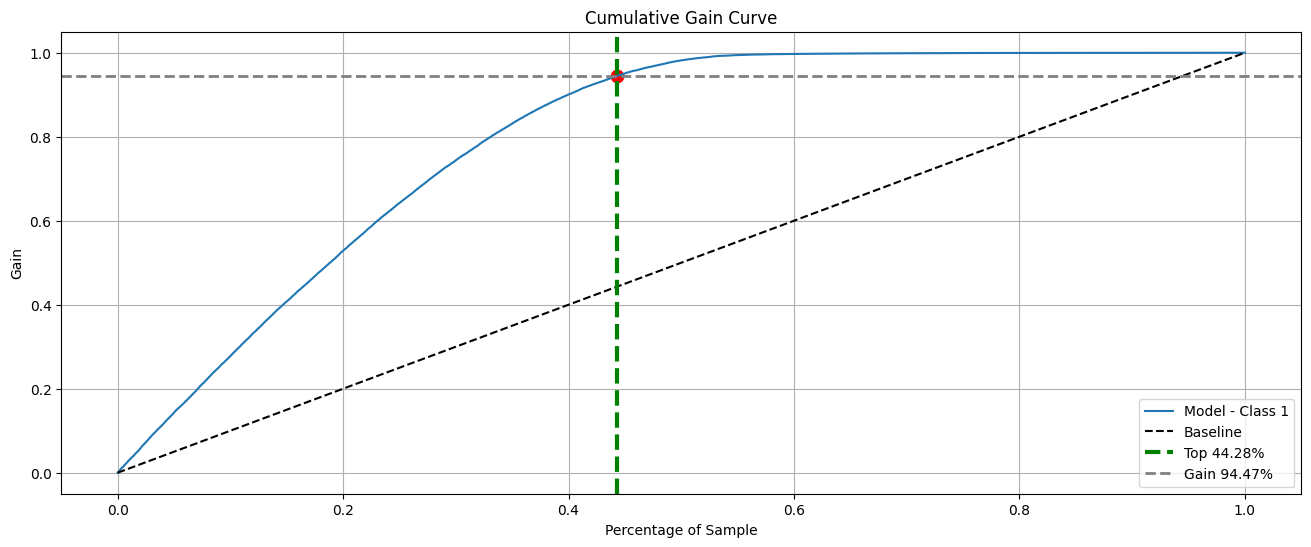

Top 44.28% da base captura 94.47% dos interessados.
O modelo é 2.13x melhor que uma escolha aleatória.


In [85]:
plot_cumulative_gain_manual(
    all_y_true,
    all_yhat,
    cutoff=0.4428,
    figsize=(16, 6)
)

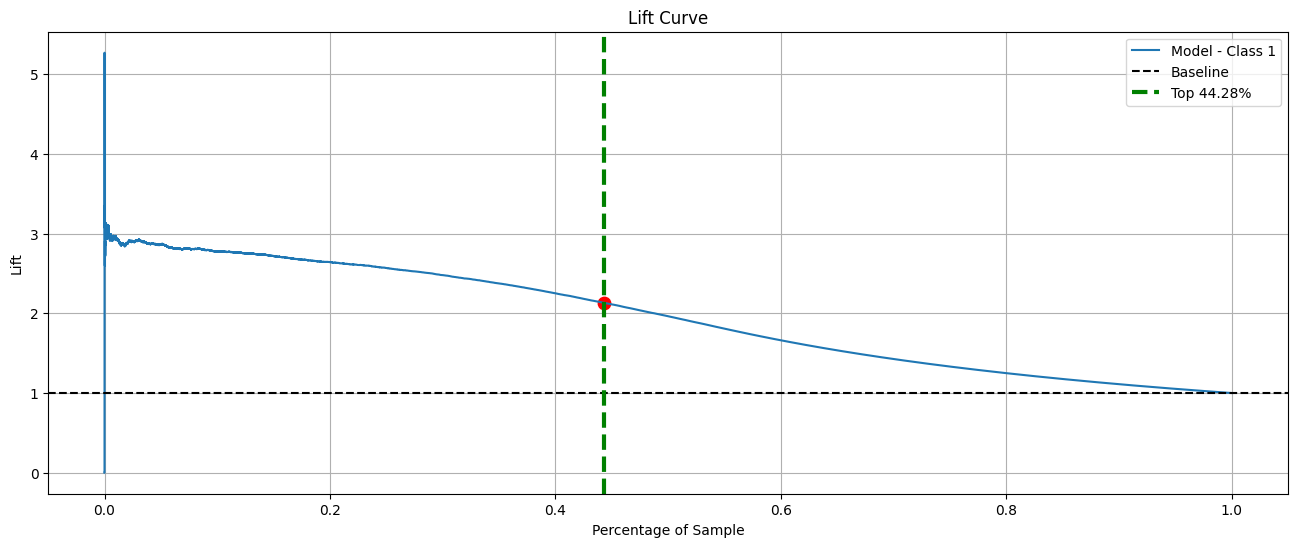

Top 44.28% da base possui lift de 2.13x.


In [88]:
plot_lift_curve_manual(
    all_y_true,
    all_yhat,
    cutoff=0.4428,
    figsize=(16, 6)
)

In [89]:
random_choice = (50/100) * len(data)
model = (94/100) * len(data)

revenue_rc = random_choice * 1000
revenue_m = model * 1000

print(f'Revenue with Random Choice: US$ {revenue_rc:,.2f}')
print(f'Revenue with Model: US$ {revenue_m:,.2f}')
print()
print(f'Difference: US$ {(revenue_m - revenue_rc):,.2f}')

Revenue with Random Choice: US$ 30,488,500.00
Revenue with Model: US$ 57,318,380.00

Difference: US$ 26,829,880.00


# 10.0 DEPLOY TO PRODUCTION

In [57]:
pickle.dump(model_rl, open('/home/ds-eduardo/propensao_classificacao/src/models/model_health_insurance.pkl','wb'))

In [58]:
import pickle
from pathlib import Path

import pandas as pd
import numpy as np


class HealthInsurance:
    def __init__(self):
        self.home_path = Path(__file__).resolve().parents[1]

        with open(self.home_path / "features" / "annual_premium_scaler.pkl", "rb") as file:
            self.annual_premium_scaler = pickle.load(file)

        with open(self.home_path / "features" / "age_scaler.pkl", "rb") as file:
            self.age_scaler = pickle.load(file)

        with open(self.home_path / "features" / "vintage_scaler.pkl", "rb") as file:
            self.vintage_scaler = pickle.load(file)

        with open(self.home_path / "features" / "target_encode_gender_scaler.pkl", "rb") as file:
            self.target_encode_gender_scaler = pickle.load(file)

        with open(self.home_path / "features" / "target_encode_region_code_scaler.pkl", "rb") as file:
            self.target_encode_region_code_scaler = pickle.load(file)

        with open(self.home_path / "features" / "fe_policy_sales_channel_scaler.pkl", "rb") as file:
            self.fe_policy_sales_channel_scaler = pickle.load(file)

    def data_cleaning(self, df1):
        df1 = df1.copy()
        df1.columns = df1.columns.str.lower()
        return df1

    def feature_engineering(self, df2):
        df2 = df2.copy()

        df2["vehicle_age"] = df2["vehicle_age"].apply(
            lambda x: "over_2_years"
            if x == "> 2 Years"
            else "between_1_2_years"
            if x == "1-2 Year"
            else "below_1_year"
        )

        df2["vehicle_damage"] = df2["vehicle_damage"].apply(
            lambda x: 1 if x == "Yes" else 0
        )

        return df2

    def data_preparation(self, df5):
        df5 = df5.copy()

        df5["annual_premium"] = self.annual_premium_scaler.transform(df5[["annual_premium"]])
        df5["age"] = self.age_scaler.transform(df5[["age"]])
        df5["vintage"] = self.vintage_scaler.transform(df5[["vintage"]])

        df5["gender"] = df5["gender"].map(self.target_encode_gender_scaler).astype(float)
        df5.loc[:, "region_code"] = df5["region_code"].map(self.target_encode_region_code_scaler)

        df5 = pd.get_dummies(df5, prefix="vehicle_age", columns=["vehicle_age"])

        df5.loc[:, "policy_sales_channel"] = df5["policy_sales_channel"].map(
            self.fe_policy_sales_channel_scaler
        )

        col_selected = [
            "vintage",
            "annual_premium",
            "age",
            "region_code",
            "vehicle_damage",
            "policy_sales_channel",
            "previously_insured",
        ]

        return df5[col_selected]

    def get_prediction(self, model, original_data, test_data):
        pred = model.predict_proba(test_data)

        original_data = original_data.copy()
        original_data["score"] = pred[:, 1]

        return original_data.to_json(orient="records", date_format="iso")

## 10.1 API Handler

In [ ]:
import pickle
from pathlib import Path

import pandas as pd
from flask import Flask, request, Response

from healthinsurance.Healthinsurance import HealthInsurance


BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "models" / "model_health_insurance.pkl"

with open(MODEL_PATH, "rb") as file:
    model = pickle.load(file)

app = Flask(__name__)


@app.route("/", methods=["GET"])
def home():
    return Response('{"status": "ok"}', status=200, mimetype="application/json")


@app.route("/health", methods=["GET"])
def health():
    return Response('{"status": "healthy"}', status=200, mimetype="application/json")


@app.route("/predict", methods=["POST"])
def health_insurance_predict():
    test_json = request.get_json()

    if not test_json:
        return Response("{}", status=200, mimetype="application/json")

    if isinstance(test_json, dict):
        test_raw = pd.DataFrame(test_json, index=[0])
    else:
        test_raw = pd.DataFrame(test_json, columns=test_json[0].keys())

    pipeline = HealthInsurance()

    df1 = pipeline.data_cleaning(test_raw)
    df2 = pipeline.feature_engineering(df1)
    df3 = pipeline.data_preparation(df2)

    df_response = pipeline.get_prediction(model, test_raw, df3)

    return Response(df_response, status=200, mimetype="application/json")


if __name__ == "__main__":
    import os

    port = int(os.environ.get("PORT", 5000))
    app.run(host="0.0.0.0", port=port, debug=False)